# TS1 - Generador de señales

Sofía Agüero - PDS - UTN

Función para generar senoidales digitalizadas + pruebas de aliasing con fs=1000Hz.

In [1]:
import numpy as np                # arrays y cuentas numericas
import matplotlib.pyplot as plt   # graficar
from scipy import signal          # onda cuadrada para el bonus

## Función generadora

In [2]:
# vmax = amplitud, dc = offset, ff = frecuencia, ph = fase, nn = cant muestras, fs = frec de muestreo

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs                       # arange me da los indices 0,1,2...nn-1; al dividir por fs paso de "muestra n" a "instante en segundos"
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)    # formula de la senoidal: dc corre la señal verticalmente, vmax la escala, y adentro del seno va la fase instantanea (arranca en ph y avanza segun ff)
    
    tt = tt.reshape(nn,1)     # lo paso a columna Nx1, asi lo pide la consigna
    xx = xx.reshape(nn,1)     # mismo motivo, y asi tt y xx quedan con la misma forma
    
    return tt, xx

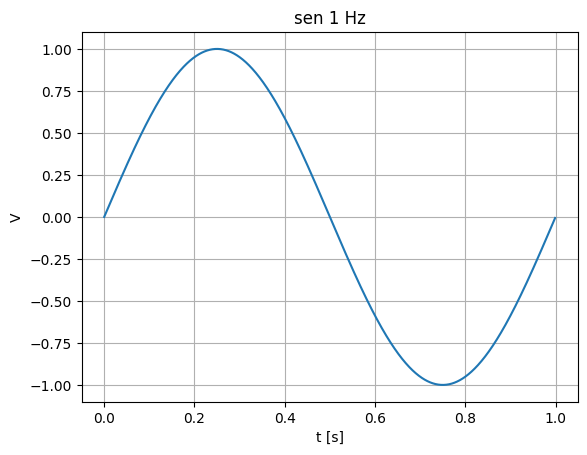

In [3]:
# pruebo que ande
N = 1000
fs = 1000                     # fs=1000Hz -> Nyquist = fs/2 = 500Hz

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs)

plt.plot(tt, xx)
plt.title('sen 1 Hz')
plt.xlabel('t [s]')
plt.ylabel('V')
plt.grid()

## Ahora las de la consigna (aliasing)

fs = 1000, entonces Nyquist = fs/2 = 500Hz. Pruebo con 500, 999, 1001 y 2001 Hz

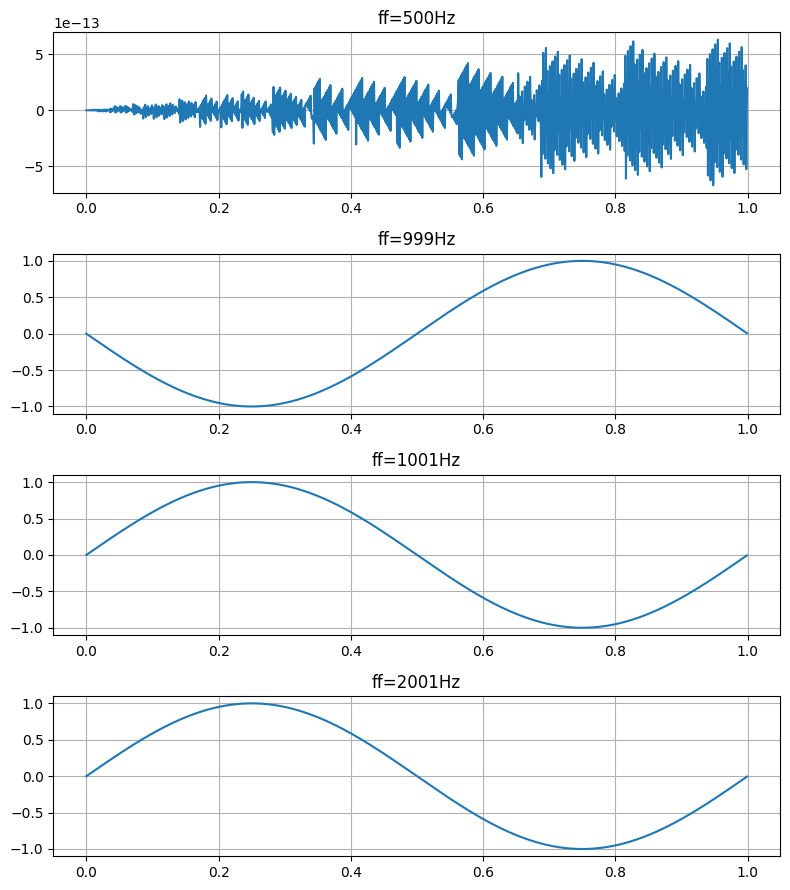

In [4]:
frecuencias = [500, 999, 1001, 2001]   # 500=Nyquist exacto; el resto esta por encima -> aliasing

fig, axs = plt.subplots(4, 1, figsize=(8,9))

for i in range(4):
    tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=frecuencias[i], ph=0, nn=N, fs=fs)
    axs[i].plot(tt, xx)                       # 999,1001,2001 se ven todas como 1Hz (mismo alias)
    axs[i].set_title(f'ff={frecuencias[i]}Hz')
    axs[i].grid()

plt.tight_layout()

**500Hz:** da todo cero. Es justo la mitad de fs (Nyquist) y con fase 0 cada muestra cae en un cruce por cero de la señal, entonces no se ve nada aunque la senoidal exista.

**999, 1001 y 2001 Hz:** las tres se ven como una senoidal de 1Hz, aunque son frecuencias totalmente distintas. esto es aliasing: al estar por encima de fs/2=500Hz, se "pliegan" y aparecen como si fueran de baja frecuencia. x eso siempre hay que muestrear a mas del doble de la frecuencia maxima que nos interesa (Nyquist), sino terminamos con señales que no podemos distinguir entre si

## Bonus: onda cuadrada

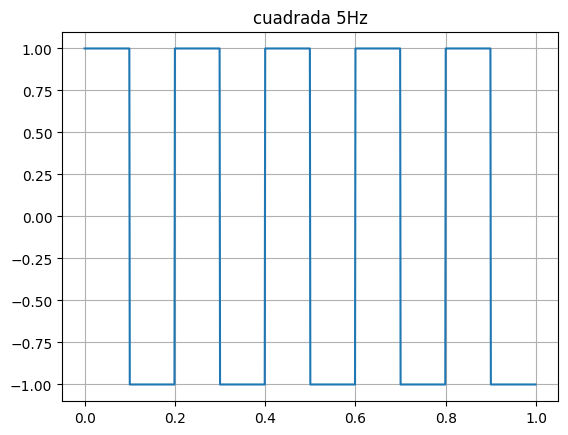

In [ ]:
# misma idea que la senoidal pero con square de scipy
def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, duty=0.5):
    tt = np.arange(nn) / fs
    xx = dc + vmax * signal.square(2*np.pi*ff*tt + ph, duty=duty)  # onda cuadrada (tiene varioss armonicos)
    
    tt = tt.reshape(nn,1)
    xx = xx.reshape(nn,1)
    
    return tt, xx

tt, xx = mi_funcion_cuadrada(vmax=1, dc=0, ff=5, ph=0, nn=1000, fs=1000)
plt.plot(tt, xx)
plt.title('cuadrada 5Hz')
plt.grid()